# Option analytics: letting a network decide what the exposures depend on

[`11a_pca`](11a_pca.ipynb) estimated exposures from the return panel alone.
[`11b_ipca`](11b_ipca.ipynb) made each stock's exposure a linear function of its own
characteristics, so the option surface reached the model for the first time. The conditional
autoencoder keeps that second shape exactly - exposures times factor returns, exposures a
function of the characteristics - and replaces the linear map with a neural network.

**So the whole difference between this notebook and `11b_ipca` is the functional form of one
map.** IPCA says a stock's loading on factor *k* is a fixed weighted sum of its characteristics.
The conditional autoencoder says it is whatever a network of those characteristics produces,
which can bend: a loading that rises with implied volatility up to a point and then falls is
available here and is not available there. Everything else - the factors, the folds, the labels,
the way a forecast is formed - is unchanged.

**It is fitted by reconstruction, not by prediction, and the difference is narrower than that
sentence usually implies.** The panel this model reconstructs is the label panel: the runner fills
its return matrix from the label column that member was configured with, so what the objective
reproduces is that member's own label - `fwd_ret_5d` for the primary one, and `fwd_ret_10d` or
`fwd_ret_risk_adj_5d` for the other two rows of the table in section 4. Whichever it is, it is
the same column that member's IC is then scored on. The objective is therefore not blind to the
target, and a positive IC is less surprising than it would be if it were.

What still separates reconstruction from forecasting is *which* returns and *how*. The fit sees
the training window's forward returns beside the characteristics of the same dates and compresses
both into a handful of factors; it is never shown a date it must then order. The forecast in step
4 below applies fixed factor means to a validation date's own exposures, which is an
extrapolation the objective never optimized and could not have. So the IC below asks whether a
compact description of one window's cross-section transfers to the next one - a real question
with an unfavourable prior, and *Chapter 14*, Section 14.5 is where the book sets out why: the
directions a cross-section co-moves along are the directions it is *risky* along, and a risk
factor is not obliged to be a return factor.

**This is the first member of the family with a genuine stopping point.** PCA and IPCA are solved:
one fold produces one answer. This one is trained, so `config/cae/cae.yaml` declares
`n_epochs: 50` and `checkpoint_interval: 5`, and the fit publishes ten prediction sets per label
rather than one. A checkpoint here is a real choice a reader could have made differently, which is
why the table below has an epoch column with ten distinct values in it.

**Learning objectives.** By the end of this notebook you will be able to:

- State what a conditional autoencoder changes relative to IPCA, and what it leaves alone.
- Explain why reconstructing one window is not forecasting the next, given that both are
  measured on the same label column, and what that predicts
  about the IC.
- Read a checkpoint schedule as a property of the estimator rather than as a tuning knob.
- Say why the epoch with the highest validation IC is not thereby selected.

**Book reference**: Chapter 14, Section 14.4 (conditional autoencoders) and Section 14.5 (what a
reconstruction objective does and does not promise). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds,
[`11_latent_factors`](11_latent_factors.ipynb) introduces the family, and
[`11b_ipca`](11b_ipca.ipynb) is the linear version of the map this notebook generalizes.

**What it writes**: one training run per label and ten complete validation prediction sets per
label - one per checkpoint - in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a population named for this model. The family splits across
five notebooks, so each publishes its own population rather than one shared one.
[`13_model_analysis`](13_model_analysis.ipynb) compares them against the other families and
[`14_backtest`](14_backtest.ipynb) selects on validation backtest Sharpe. **Selection happens
there, not here.**

In [1]:
"""Fit the declared option-analytics conditional-autoencoder population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

MODEL_NAME = "cae"

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="11c_conditional_autoencoder",
)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and the cell below reads
which those are rather than this sentence asserting a count that would go stale the moment a
sixth label declared the family. What the names mean is the part prose has to supply:
`fwd_ret_5d` is the stock's total return over the five trading days after the decision date,
`fwd_ret_10d` the same over ten, and `fwd_ret_risk_adj_5d` the five-day return divided by a
measure of its own dispersion. A `fwd_dir_*` classification label declaring only linear and
gradient boosting is absent here rather than dropped.

In [4]:
declared_labels(study, "latent_factors")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

`case_studies/config/cae/cae.yaml` declares three values. `n_factors` is the width of the
bottleneck - how many common movements the network is allowed to describe the cross-section with.
`n_epochs` is how long it trains, and `checkpoint_interval` is how often it stops to publish, so
together they say the fit publishes at epochs 5 through 50 in steps of five.

The interval is what makes this notebook's table taller than
[`11a_pca`](11a_pca.ipynb)'s. Ten checkpoints per label is not ten models to choose between here;
it is one training run observed at ten points, all of which are published so that
[`14_backtest`](14_backtest.ipynb) can carry the whole schedule into its own sweep rather than
inheriting a choice made on IC.

The case study may override any of these under `modeling.latent_factors.model_kwargs` in
`config/setup.yaml`, which wins where it is given; this one declares entries for `ipca` and `sdf`
only, so the conditional autoencoder's values are the preset's. A reduced run may then override
them again through `PREVIEW_REDUCTIONS`, where the reduction becomes part of the preview identity.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""latent_factors""","""fwd_ret_10d""","""cae""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_5d""","""cae""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_risk_adj_5d""","""cae""","""""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across five notebooks and each publishes one model, so the complete
catalog is five times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### Where this one runs, and why the family's declaration is the right one here

`config/setup.yaml` declares the latent-factor family on CUDA. That declaration exists because the
device sits inside the hashed computation rather than beside it as provenance: with no value
declared, the library falls back to whichever device the machine happens to have, and the training
identity becomes a property of the host.

[`11a_pca`](11a_pca.ipynb) and [`11b_ipca`](11b_ipca.ipynb) override it to `cpu`, because their
runners are numpy and scipy and take no device at all. This one is a torch model that is actually
trained on the declared device, so it takes the family's value unchanged and passes no override.
A run on a machine without CUDA therefore computes something different and must publish under its
own name - which is the declaration working as intended rather than an obstacle.

A machine without a card cannot run the declared device at all, and the library refuses to
substitute one: the latent-factor runtime raises when CUDA is declared and unavailable rather
than falling back to the CPU, because a silent fallback changes what was fitted. `DEVICE` names the
device such a run fits on. It travels with `POPULATION_NAME`, because the device it names is
inside the training identity: the run computes a different member set and has to publish under
its own name rather than into the population the declaration describes.

In [7]:
overrides: dict = {"device": DEVICE} if DEVICE else {}
print(f"training device: {DEVICE or 'the family declaration in config/setup.yaml (cuda)'}")

training device: the family declaration in config/setup.yaml (cuda)


## 2. Binding the declarations to the data

A menu entry names an estimator, a factor count and an epoch schedule. It does not say which
feature columns exist today, where the walk-forward folds fall, or which symbol-date pairs have
both a return and a label. **Planning** works all of that out - and every training and prediction
identity with it - without fitting anything. Four things to check:

- **`feature_count` and `eligible_rows` agree across the rows.** A row that differs is a label
  measured on a different sample from its neighbours. They differ *between* labels, because a
  ten-day forward window runs out earlier than a five-day one.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out 2021 tail visible.
- **`checkpoints` is 10**, which is the schedule the configuration declares, read back from the
  plan rather than assumed.

`feature_count` means something here that it did not mean in
[`11a_pca`](11a_pca.ipynb). There it counted columns the decomposition never touched; here every
one of them is an input to the network that produces the exposures, so it is the width of the map
this notebook exists to generalize.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_ret_10d""","""cae""","""regression""",48,192139,2,10,"""2019-01-07 00:00:00""","""2020-12-16 00:00:00"""
"""fwd_ret_5d""","""cae""","""regression""",48,194813,2,10,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""
"""fwd_ret_risk_adj_5d""","""cae""","""regression""",48,194748,2,10,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [9]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded conditional-autoencoder menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

3 label-configuration pairs
3 training identities
30 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. takes the characteristics of every stock in that fold's training window and passes them
   through a network that outputs `n_factors` exposures per stock,
2. solves for the factor returns that, applied to those exposures, best reproduce that window's
   values of this member's own label column - the same column section 4 then scores it against,
3. backpropagates the reconstruction error into the network, repeating for the declared number of
   epochs and publishing whenever the checkpoint schedule says so,
4. forecasts each validation date by applying the fitted network to that date's characteristics
   and the training window's mean factor returns to the exposures it produces.

Step 4 is where the conditioning pays or does not. The network is fixed after training, but the
characteristics it is applied to are the validation date's own - so a stock whose option surface
changed between fitting and forecasting gets different exposures without anything being refitted.
That is the property [`11a_pca`](11a_pca.ipynb) does not have and cannot acquire.

**This notebook passes the plan rather than resolved requests, and on this family that changes
what the plan table can show rather than how the fitting is ordered.** The linear, boosted and
TabM adapters each provide a batch runner that prepares one fold set for several configurations;
the latent-factor adapter provides none, so every request is fitted on its own whichever path is
taken. There would be nothing to share in any case: this notebook publishes one model against
three labels, and each label is a different set of rows. What passing the plan costs is
`eligible_entities`, which needs the eligibility keys themselves; `eligible_rows` above moves
whenever the universe does, so the check that column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [10]:
def catalog_labels(execution) -> int:
    """Number of distinct labels the execution published, read from its catalog rows."""
    return execution.catalog_rows.get_column("label").n_unique()


population_name = POPULATION_NAME or f"sp500_equity_option_analytics-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

# No per-fold counts: this family's runner reports none, and two zeros would read as a failed fit.
print(f"{len(execution.runs)} training runs across {catalog_labels(execution)} labels")
print(f"population {population.name}: {len(population.members)} prediction sets")

Latent factor CV: 1 models × 2 folds
Log file: case_studies/sp500_equity_option_analytics/run_log/training/e7cc7a9e56e9/.models.3479a0649cc64f949bd3799c10b4e4fb.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=50
  cae (K=5):


    Fold 0: ragged train=475, val=251, max_N=503


      fold 0: reported_epoch=50, IC=-0.0051, 19.7s


    Fold 1: ragged train=493, val=241, max_N=503


      fold 1: reported_epoch=50, IC=-0.0205, 19.8s


...

      fold 0: reported_epoch=50, IC=+0.0089, 139.5s


    Fold 1: ragged train=498, val=246, max_N=503


      fold 1: reported_epoch=50, IC=-0.0081, 141.9s


    -> reporting epoch=50 (fixed), IC=+0.0005 (289.3s)
  Best: cae (IC=+0.0005)


3 training runs across 3 labels
population sp500_equity_option_analytics-cae-validation-v1: 30 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows, and the runner returns the stored result rather than fitting
again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "latent_factors", labels=["fwd_ret_5d"], config_names=["cae"]
)
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-cae-v1")
```

To change the bottleneck width or the epoch schedule for your own run, edit
`case_studies/config/cae/cae.yaml`, or declare the value under
`modeling.latent_factors.model_kwargs.cae` in `config/setup.yaml` to override the preset for this
case study alone. Note which of those you want: the preset is shared by every case study that
declares `cae`, so editing it moves the training identity of all of them. Either way the result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label and checkpoint. The **information coefficient** is the rank correlation, on one
validation date, between the stocks ordered by the model's prediction and the stocks ordered by
the return they went on to earn.

`ic_mean` aggregates that **over folds, not over days**: each fold's own mean IC is computed and
those are averaged with equal weight (`latent_factors/cv.py`, and the convention is stated in
`registry/metrics.py`). With folds of unequal length the fold mean and the pooled daily mean are
different numbers, and this column is the first.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which rows
are comparable with each other. `auc_scored_against` says what the AUC column was scored against:
a regression row has no classes of its own and is scored as a ranking signal against a declared
direction sibling, so `fwd_ret_5d` is scored against `fwd_dir_5d` and `fwd_ret_10d` against
`fwd_dir_10d`. `fwd_ret_risk_adj_5d` declares no sibling and carries no AUC; null there means not
computed, not zero.

The published catalog is checked against the population planned before fitting rather than against
its own row count, because a run that lost a member would otherwise report a shorter table and
nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    pl.col("direction_label").alias("auc_scored_against"),
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label", "checkpoint_value")

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError(
        "a partial conditional-autoencoder prediction set cannot pass to backtesting"
    )
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label and checkpoint must identify one prediction set")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select(
    "label",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    "auc_scored_against",
)

30 candidate models across 3 labels


label,checkpoint_value,ic_mean,ic_std,ic_t,ic_n_days,auc_mean_daily,auc_scored_against
str,i64,f64,f64,f64,f64,f64,str
"""fwd_ret_10d""",5,0.004772,0.001246,5.415274,492.0,0.498672,"""fwd_dir_10d"""
"""fwd_ret_10d""",10,0.009252,0.006198,2.111202,492.0,0.501857,"""fwd_dir_10d"""
"""fwd_ret_10d""",15,0.010299,0.010273,1.417705,492.0,0.504785,"""fwd_dir_10d"""
"""fwd_ret_10d""",20,0.007783,0.010535,1.044702,492.0,0.507989,"""fwd_dir_10d"""
"""fwd_ret_10d""",25,0.00382,0.006712,0.804927,492.0,0.508243,"""fwd_dir_10d"""
…,…,…,…,…,…,…,…
"""fwd_ret_risk_adj_5d""",30,-0.000997,0.000997,-1.414667,497.0,null,null
"""fwd_ret_risk_adj_5d""",35,-0.002448,0.002106,-1.643499,497.0,null,null
"""fwd_ret_risk_adj_5d""",40,-0.001976,0.004158,-0.672134,497.0,null,null


### Where each label's schedule reached its highest IC

Ten checkpoints per label is too many rows to read as a table, so this reduces each label to the
epoch with its highest validation IC. Two columns are there to stop that number being read as
more than it is. `epochs_above_zero` counts how many of the ten checkpoints put the IC on the
positive side at all, which separates a model that is consistently weak from one that crossed zero
once. `ic_t` is the t-statistic across those fold means rather than a
Newey-West statistic on the daily series - the registry keeps that separately as `ic_t_hac`, and
it is the inferential one. Either way `ic_t` is a diagnostic and not a selection rule - the series is short, overlapping multi-day returns make successive days
dependent, and the folds have been read many times over by the time a case study reaches this
notebook.

**Reading the highest of ten checkpoints is itself a selection**, and reporting it without saying so
would overstate what the model achieved. It is shown because the shape of the schedule is the
thing worth seeing; nothing downstream inherits it.

In [12]:
by_label = (
    catalog.sort("ic_mean", descending=True)
    .group_by("label", maintain_order=True)
    .agg(
        best_epoch=pl.col("checkpoint_value").first(),
        best_ic=pl.col("ic_mean").first(),
        ic_t=pl.col("ic_t").first(),
        epochs_above_zero=(pl.col("ic_mean") > 0).sum(),
        checkpoints=pl.len(),
        scored_dates=pl.col("ic_n_days").first(),
    )
    .sort("best_ic", descending=True)
)
by_label

label,best_epoch,best_ic,ic_t,epochs_above_zero,checkpoints,scored_dates
str,i64,f64,f64,u32,u32,f64
"""fwd_ret_10d""",15,0.010299,1.417705,5,10,492.0
"""fwd_ret_5d""",10,0.004774,3.388774,7,10,497.0
"""fwd_ret_risk_adj_5d""",10,0.002689,1.205749,5,10,497.0


### What training longer does to the ranking

One line per label across the published schedule, on one axis. A reconstruction objective has no
reason to improve the IC as it improves, so this chart is where that expectation is either met or
not: a line that wanders without trend is a model whose fit and whose usefulness are unrelated,
which is a finding rather than a failure. The shared axis keeps the distance between labels
readable instead of each panel filling itself.

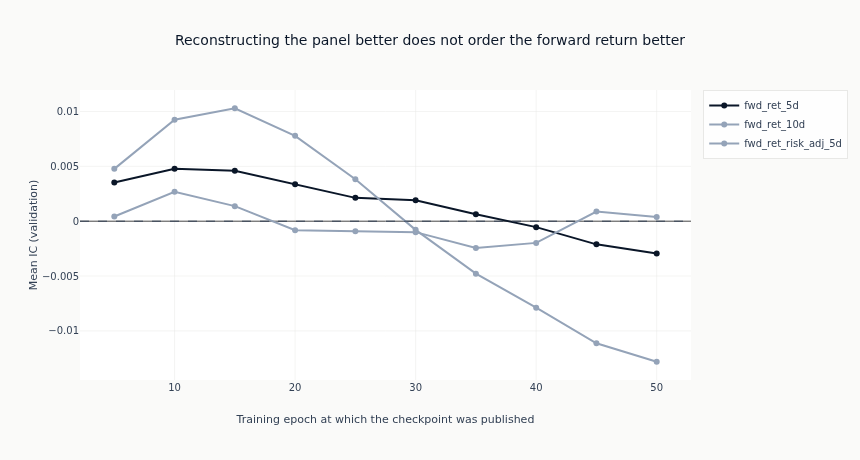

In [13]:
fig = go.Figure()
for index, label in enumerate(ordered_labels):
    rows = catalog.filter(pl.col("label") == label).sort("checkpoint_value")
    fig.add_trace(
        go.Scatter(
            x=rows.get_column("checkpoint_value").to_list(),
            y=rows.get_column("ic_mean").to_list(),
            mode="lines+markers",
            name=label,
            line=dict(color=COLORS["blue"] if label == primary else COLORS["recede"]),
            marker=dict(color=COLORS["blue"] if label == primary else COLORS["recede"]),
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_xaxes(title_text="Training epoch at which the checkpoint was published")
fig.update_layout(
    title="Reconstructing the panel better does not order the forward return better",
    height=460,
    width=860,
    margin=dict(t=90),
)
# The direction of each line is a fact about the frame, so the alt text counts it rather than
# asserting a shape the next run may not reproduce.
spans = "; ".join(
    f"{row['label']} spans {row['lo']:+.4f} to {row['hi']:+.4f}"
    for row in catalog.group_by("label")
    .agg(lo=pl.col("ic_mean").min(), hi=pl.col("ic_mean").max())
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Line chart of mean validation information coefficient against the training epoch at which "
    "each checkpoint was published, one line per label on one axis, the primary target in dark "
    f"navy and the two variants in light slate, with a dashed zero line. Counted from the frame: "
    f"{spans}.",
)

## 5. What to notice

**The map is the only thing that changed, so the comparison with `11b_ipca` is clean.** Same
factors, same folds, same labels, same forecast construction. Whatever separates the two rows in
[`13_model_analysis`](13_model_analysis.ipynb) is attributable to linear-versus-network and to
nothing else, which is a rarer thing than it sounds and is the reason the family is split this
way.

**Reconstructing a window is not forecasting the next one, and the epoch chart is where that
stops being a caveat and becomes a measurement.** Training reduces reconstruction error on the
training window by construction, and it reduces it against the very column the IC is computed on -
so this is not a case of two unrelated quantities happening to agree. Whether driving that error
down on one window raises the IC on the next is the empirical question, and the schedule answers
it directly. *Chapter 14*, Section 14.5 sets out why the answer is often no.

**More capacity than IPCA is not more information than IPCA.** The network sees exactly the
characteristics the linear map saw. It can represent more functions of them, which helps only if
the true relation is one of the functions IPCA could not reach. Where it is not, the extra
capacity finds structure in the training window that does not survive into the validation one -
the standard bargain, and one the shared target makes easier to lose rather than harder, because
the extra capacity is spent fitting the training window's own forward returns more exactly.

**Ten checkpoints are ten observations of one fit, not ten candidates.** They are published so
that [`14_backtest`](14_backtest.ipynb) can carry the entire schedule into its own sweep and
select on validation backtest Sharpe. Reading the highest IC off this notebook and stopping there
would be selecting on a quantity that measures ranking rather than money, before costs and
turnover have been applied to any of it.

**Known limitations.** Two folds, one of them validating on 2020, a year in which the
cross-section co-moved unlike any other in the sample - which bears on a factor model more
directly than on a supervised one, because co-movement is the thing being estimated. The factor
count and the network's shape are declared rather than chosen, and nothing here tests whether
another setting would order the cross-section better; that would be a search, and a search over
validation IC is what this notebook is arranged to avoid. The IC carries no adjustment for the
serial dependence overlapping multi-day returns create, so it is a ranking diagnostic rather than
a test. Training is stochastic in a way the two solved members are not, so a rerun on different
hardware reproduces the identity but not necessarily the third decimal place.

**Next**: [`11d_stochastic_discount_factor`](11d_stochastic_discount_factor.ipynb) drops the
two-stage shape this notebook shares with IPCA. Instead of estimating exposures and then applying
factor returns to them, it estimates the pricing kernel directly from a no-arbitrage moment
condition, which is a different argument about what the cross-section is rather than a different
functional form for the same one.